# Машинное обучение

## Практическое задание №1

Проанализируйте данные о мировом рынке вакансий в сфере ИИ в 2025 году.

Файл `ai_job_dataset_upd.csv` содержит следующие признаки:

| Variable name | Variable description
|:-------------------:|:------------------:|
| job_id | Unique identifier for each job posting |
| job_title | Standardized job title | 
| salary_usd | Annual salary in USD| 
| salary_currency | Original salary currency| 
| salary_local | Salary in local currency| 
| experience_level | EN (Entry), MI (Mid), SE (Senior), EX (Executive)| 
| employment_type |	FT (Full-time), PT (Part-time), CT (Contract), FL (Freelance)| 
| company_location | Country where company is located| 	
| company_size | S (Small <50), M (Medium 50-250), L (Large >250)| 
| employee_residence |	Country where employee resides|
| remote_ratio | 0 (No remote), 50 (Hybrid), 100 (Fully remote)|
| required_skills |	Top 5 required skills (comma-separated)|
| education_required |	Minimum education requirement|
| years_experience | Required years of experience|
| industry | Industry sector of the company |
| posting_date | Date when job was posted |
| application_deadline | Application deadline |
| job_description_length | Character count of job description |
| benefits_score |	Numerical score of benefits package (1-10) |

Исполнители: **Дараган Даниил Дмитриевич, Привезенцев Даниил Алексеевич, МСПИН-251**

### 1. Описание набора данных

В наборе 15 000 записей и 19 признаков.
В таблице нет заявленного в условии `salary_local`, зато есть `company_name`.

Пропуски встречаются в `benefits_score`, `salary_usd`, `job_description_length`, `education_required`, `industry` и `employee_residence`.
В каждом из этих признаков меньше 20 пропусков. Их немного, но это не доказывает случайность их появления.
Способ обработки выберем в пункте 4.

Признаки представлены в нескольких форматах:
1. `salary_usd`, `years_experience`, `job_description_length`, `benefits_score`: числовые признаки.
2. `experience_level`, `company_size`, `education_required`: категории с естественным порядком.
3. `job_id`, `job_title`, `salary_currency`, `employment_type`, `company_location`, `employee_residence`, `required_skills`, `industry`, `company_name`: текстовые поля типа `object`. `required_skills` содержит список навыков.
4. `remote_ratio` принимает значения 0, 50 и 100. Они обозначают офисный, гибридный и удалённый форматы работы. Для сравнения частот будем рассматривать их как категории.
5. `posting_date` и `application_deadline`: даты отдельных вакансий. Сейчас они записаны строками. В пункте 4 преобразуем их в `datetime`.


In [1]:
# здесь можно написать код - знаем, понимаем, предоставляем:
import pandas as pd

df = pd.read_csv('ai_job_dataset_upd.csv', sep=';')

print(f"Записей: {df.shape[0]}")
print(f"Признаков: {df.shape[1]}\n")

missing = df.isnull().sum()
print("Пропущенные значения:")
print(missing[missing > 0], "\n")

print("Типы данных:")
print(df.dtypes)

Записей: 15000
Признаков: 19

Пропущенные значения:
salary_usd                10
employee_residence         2
education_required         5
industry                   3
job_description_length     8
benefits_score            16
dtype: int64 

Типы данных:
job_id                     object
job_title                  object
salary_usd                float64
salary_currency            object
experience_level           object
employment_type            object
company_location           object
company_size               object
employee_residence         object
remote_ratio                int64
required_skills            object
education_required         object
years_experience            int64
industry                   object
posting_date               object
application_deadline       object
job_description_length    float64
benefits_score            float64
company_name               object
dtype: object


## 2. Одномерный разведочный анализ данных (EDA)

Выберем пять признаков с разными шкалами. Это позволит сравнить несколько методов анализа:

- `salary_usd`: годовая зарплата, количественный признак;
- `years_experience`: требуемый стаж в годах, дискретный количественный признак;
- `benefits_score`: числовая оценка соцпакета по шкале от 1 до 10;
- `experience_level`: порядковая категория уровня опыта;
- `remote_ratio`: категория формата работы со значениями 0, 50 и 100.

### 2.1. Годовая зарплата `salary_usd`

Рассмотрим форму распределения и крайние значения годовой зарплаты.
Построим гистограмму и ящичную диаграмму в логарифмическом масштабе.
Это позволяет показать основную часть зарплат и значения в десятках миллионов на одной шкале.
Также рассчитаем описательные статистики.


Статистика salary_usd:
count        14,990
mean        123,207
std         825,496
min            -999
25%          70,155
50%          99,618
75%         146,399
max      99,999,999
Name: salary_usd, dtype: object
Пропуски: 10


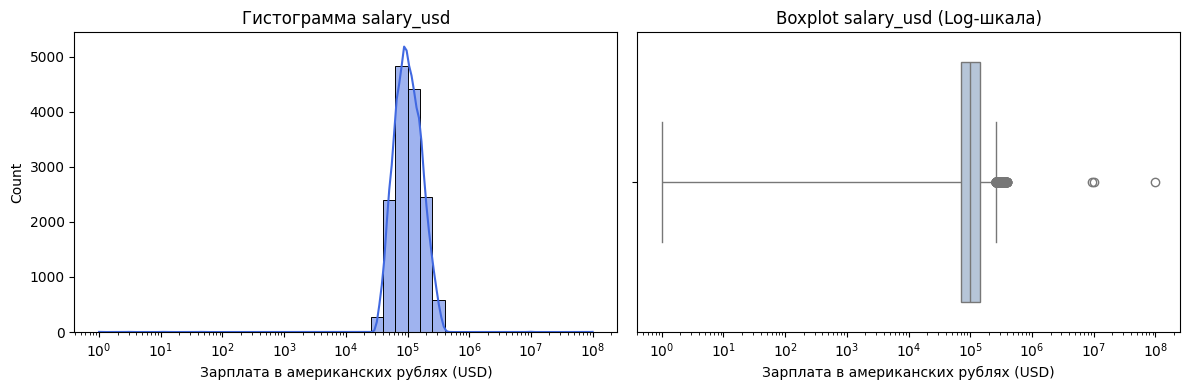

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.ticker as ticker

df = pd.read_csv('ai_job_dataset_upd.csv', sep=';')

# Статистика по всем данным
print("Статистика salary_usd:")
print(df['salary_usd'].describe().apply(lambda x: f"{x:,.0f}"))
print(f"Пропуски: {df['salary_usd'].isna().sum()}")

# Исключаем отрицательные значения только для графика, 
# ибо логарифм от отрицательного числа взять нельзя
plot_data = df[df['salary_usd'] > 0]['salary_usd']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Гистограмма с лог-шкалой
sns.histplot(plot_data, bins=40, kde=True, log_scale=True, ax=axes[0], color='royalblue')
axes[0].set_title('Гистограмма salary_usd')
axes[0].set_xlabel('Зарплата в американских рублях (USD)')

# Боксплот с лог-шкалой
sns.boxplot(x=plot_data, ax=axes[1], color='lightsteelblue')
axes[1].set_xscale('log')
axes[1].set_title('Boxplot salary_usd (Log-шкала)')
axes[1].set_xlabel('Зарплата в американских рублях (USD)')

plt.tight_layout()
plt.show()

**Результаты.** На гистограмме заметен пик около 100 тыс. USD.
Синяя линия показывает сглаженную оценку плотности. У распределения есть правый хвост.

Половина положительных зарплат находится между 70 и 146 тыс. USD.
Медиана составляет около 100 тыс. USD: 99 642 USD до очистки.

На ящичной диаграмме видны значения около 10 и 100 млн USD.
В описательной статистике есть отрицательные зарплаты, например −999.
Большие значения выглядят подозрительно, но без первоисточника нельзя подтвердить ошибку.

В пункте 4 отметим неположительные и сомнительные зарплаты как пропуски по указанному правилу.
Строки без достоверной зарплаты сохраним отдельно для возможного прогнозирования.
Заполнять целевую переменную медианой не будем.


### 2.2. Требуемый стаж `years_experience`

Посмотрим, какой стаж чаще встречается в вакансиях, и проверим крайние значения.
Построим гистограмму и ящичную диаграмму. Дополнительно рассчитаем описательные статистики.


--- Описательная статистика years_experience ---
count    15,000.00
mean          6.25
std           5.55
min           0.00
25%           2.00
50%           5.00
75%          10.00
max          19.00
Name: years_experience, dtype: object
Количество пропусков: 0


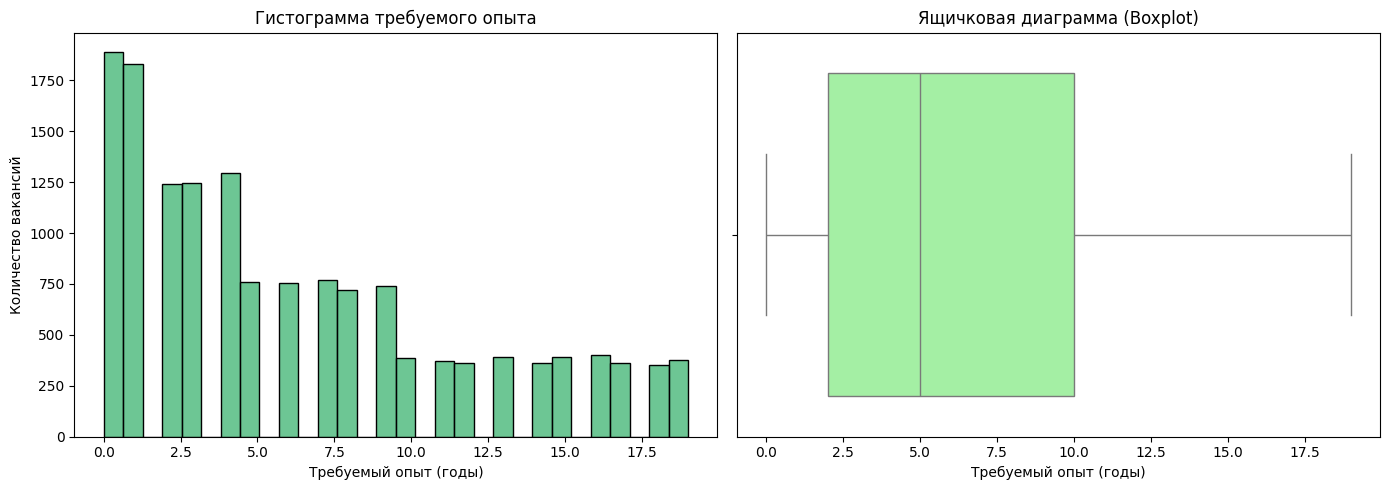

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Описательные статистики
print("--- Описательная статистика years_experience ---")
print(df['years_experience'].describe().apply(lambda x: f"{x:,.2f}"))
print(f"Количество пропусков: {df['years_experience'].isna().sum()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма
sns.histplot(df['years_experience'], bins=30, kde=False, ax=axes[0], color='mediumseagreen', edgecolor='black')
axes[0].set_title('Гистограмма требуемого опыта')
axes[0].set_xlabel('Требуемый опыт (годы)')
axes[0].set_ylabel('Количество вакансий')

# Ящик с усами
sns.boxplot(x=df['years_experience'], ax=axes[1], color='palegreen')
axes[1].set_title('Ящичковая диаграмма (Boxplot)')
axes[1].set_xlabel('Требуемый опыт (годы)')

plt.tight_layout()
plt.show()

**Результаты.** Самая высокая частота приходится на стаж от 0 до 2 лет.
Далее число вакансий снижается. После 10 лет частоты невысокие и примерно стабильные вплоть до 19 лет.

Половина значений находится между 2 и 10 годами. Медиана равна 5 годам.
Усы диаграммы охватывают весь диапазон от 0 до 19 лет.

Пропусков и точек за усами нет. Значения стажа выглядят допустимыми.
Дополнительная очистка этого признака не требуется.


### 2.3. Оценка соцпакета `benefits_score`

По словарю допустимы оценки от 1 до 10.
Проверим этот диапазон и наличие пропусков.
Для этого построим гистограмму и ящичную диаграмму.


--- Описательная статистика benefits_score ---
count    14984.000000
mean         8.171016
std         81.636659
min          5.000000
25%          6.200000
50%          7.500000
75%          8.800000
max       9999.000000
Name: benefits_score, dtype: float64
Количество пропусков: 16


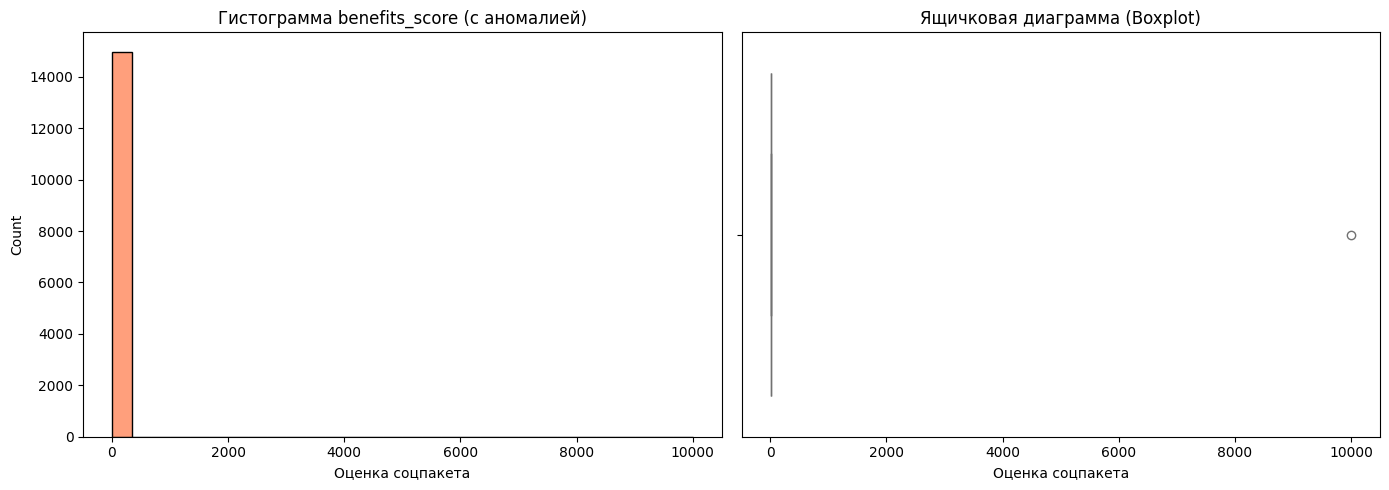

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Описательная статистика benefits_score ---")
print(df['benefits_score'].describe())
print(f"Количество пропусков: {df['benefits_score'].isna().sum()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['benefits_score'], bins=30, ax=axes[0], color='coral', edgecolor='black')
axes[0].set_title('Гистограмма benefits_score (с аномалией)')
axes[0].set_xlabel('Оценка соцпакета')

sns.boxplot(x=df['benefits_score'], ax=axes[1], color='lightsalmon')
axes[1].set_title('Ящичковая диаграмма (Boxplot)')
axes[1].set_xlabel('Оценка соцпакета')

plt.tight_layout()
plt.show()

**Результаты.** Одно экстремальное значение сильно растянуло шкалу обоих графиков.
На гистограмме допустимые оценки слились в узкий столбик слева. На ящичной диаграмме справа видна отдельная точка.

Максимум равен 9999. Это выходит за заявленную шкалу от 1 до 10.
Также найдено 16 пропусков.

Заменим 9999 на `NaN`. Затем заполним пропуски медианой обучающей части в пункте 4.


### 2.4. Уровень опыта `experience_level`

Рассмотрим доли вакансий с уровнями EN, MI, SE и EX.
Признак порядковый. Для описания категорий можно использовать моду и медианную категорию.
Здесь нас интересует всё распределение, поэтому посчитаем частоты и доли.
Построим столбиковую и круговую диаграммы.


--- Частотный анализ experience_level ---
                  Абсолютная частота  Доля (%)
experience_level                              
MI                              3781      25.2
EX                              3760      25.1
SE                              3741      24.9
EN                              3718      24.8

Пропуски: 0


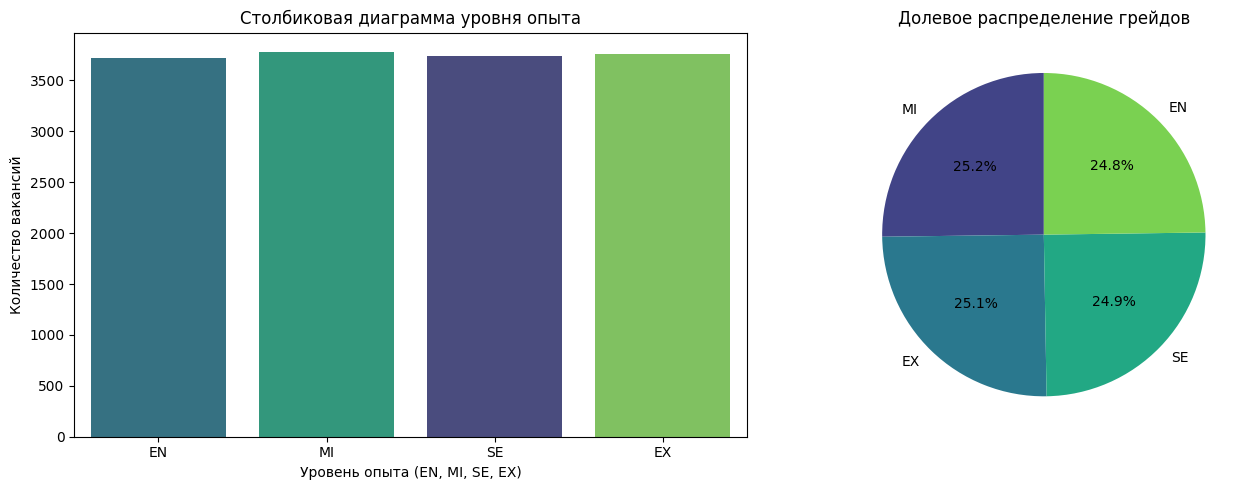

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Частотный анализ
print("--- Частотный анализ experience_level ---")
freq_table = df['experience_level'].value_counts().to_frame(name='Абсолютная частота')
freq_table['Доля (%)'] = (df['experience_level'].value_counts(normalize=True) * 100).round(1)
print(freq_table)
print(f"\nПропуски: {df['experience_level'].isna().sum()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Столбиковая диаграмма
order = ['EN', 'MI', 'SE', 'EX']
sns.countplot(data=df, x='experience_level', hue='experience_level', order=order, ax=axes[0], palette='viridis', legend=False)
axes[0].set_title('Столбиковая диаграмма уровня опыта')
axes[0].set_xlabel('Уровень опыта (EN, MI, SE, EX)')
axes[0].set_ylabel('Количество вакансий')

# Круговая диаграмма
axes[1].pie(freq_table['Абсолютная частота'], labels=freq_table.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('viridis', 4))
axes[1].set_title('Долевое распределение грейдов')

plt.tight_layout()
plt.show()

**Результаты.** Доли четырёх уровней близки к 25%.
Равномерность может быть связана со способом формирования учебной выборки.
По одному распределению происхождение данных установить нельзя.

Технических ошибок и пропусков не найдено.
Уровни имеют естественный порядок, поэтому можно проверить порядковое кодирование:
EN = 0, MI = 1, SE = 2, EX = 3.
Такое кодирование задаёт равные числовые расстояния между соседними уровнями. Это отдельное допущение.
В пункте 4 сравним его с OHE.


### 2.5. Формат работы `remote_ratio`

Значения 0, 50 и 100 обозначают офисный, гибридный и полностью удалённый форматы.
Сравним, как часто они встречаются в файле.
Для этого используем частоты, доли и столбиковую диаграмму.


--- Частотный анализ remote_ratio ---
              Количество  Доля (%)
remote_ratio                      
0                   5075      33.8
50                  5005      33.4
100                 4920      32.8

Пропуски: 0


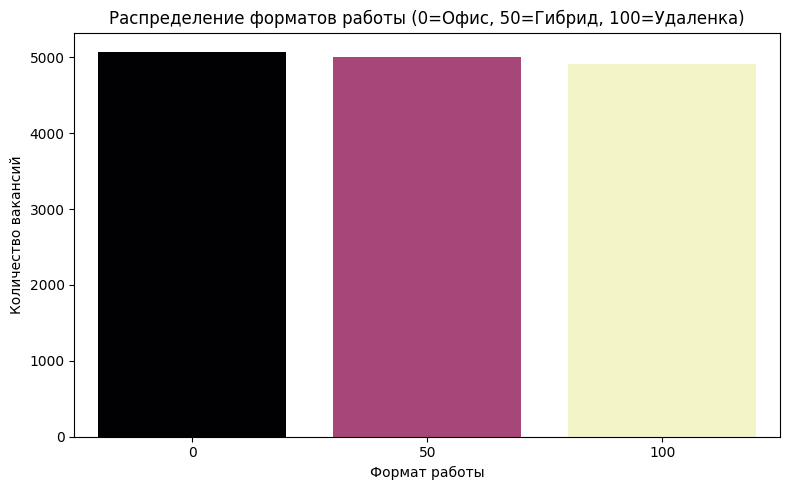

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Частотный анализ
print("--- Частотный анализ remote_ratio ---")
freq_remote = df['remote_ratio'].value_counts().to_frame(name='Количество')
freq_remote['Доля (%)'] = (df['remote_ratio'].value_counts(normalize=True) * 100).round(1)
print(freq_remote)
print(f"\nПропуски: {df['remote_ratio'].isna().sum()}")

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='remote_ratio', hue='remote_ratio', palette='magma', 
              order=[0, 50, 100], legend=False)
plt.title('Распределение форматов работы (0=Офис, 50=Гибрид, 100=Удаленка)')
plt.xlabel('Формат работы')
plt.ylabel('Количество вакансий')

plt.tight_layout()
plt.show()

**Результаты.** На офисный формат приходится 33,8% вакансий, на гибридный 33,4%, на удалённый 32,8%.
Недопустимых значений и пропусков нет.

Доли близки, как и для `experience_level`.
Это может быть связано со способом формирования учебной выборки.
Само распределение не доказывает искусственную балансировку данных.

Для модели проверим OHE. Это позволит оценивать влияние каждой категории отдельно.
При использовании исходных чисел линейная модель предполагала бы одинаковое изменение эффекта при переходах от 0 к 50 и от 50 к 100.


## 3. Двумерный разведочный анализ данных (EDA)
### 3.1. Корреляции и графики

Целевая переменная: `salary_usd`.
Выберем пять признаков: `years_experience`, `benefits_score`, `job_description_length`, `experience_level`, `company_size`.
Оценим силу, направление и значимость связей с зарплатой. Также рассмотрим связи между самими признаками.

Используем ранговую корреляцию Спирмена.
Она подходит для монотонных связей и порядковых признаков, а также меньше зависит от крайних значений.
Одна лишь асимметрия распределений не запрещает использование коэффициента Пирсона.

Построим три типа графиков:
- матрицу корреляций для сравнения всех пар;
- диаграмму рассеяния для зарплаты и стажа;
- ящичные диаграммы зарплаты по уровням опыта.


--- Статистическая значимость корреляций с salary_usd (Спирмен) ---
years_experience: r = 0.791 | p-value = 0.000e+00 | Значима (p < 0.05)
benefits_score: r = -0.005 | p-value = 5.115e-01 | НЕ значима
job_description_length: r = -0.006 | p-value = 4.442e-01 | НЕ значима
exp_num: r = 0.815 | p-value = 0.000e+00 | Значима (p < 0.05)
size_num: r = 0.193 | p-value = 4.441e-126 | Значима (p < 0.05)


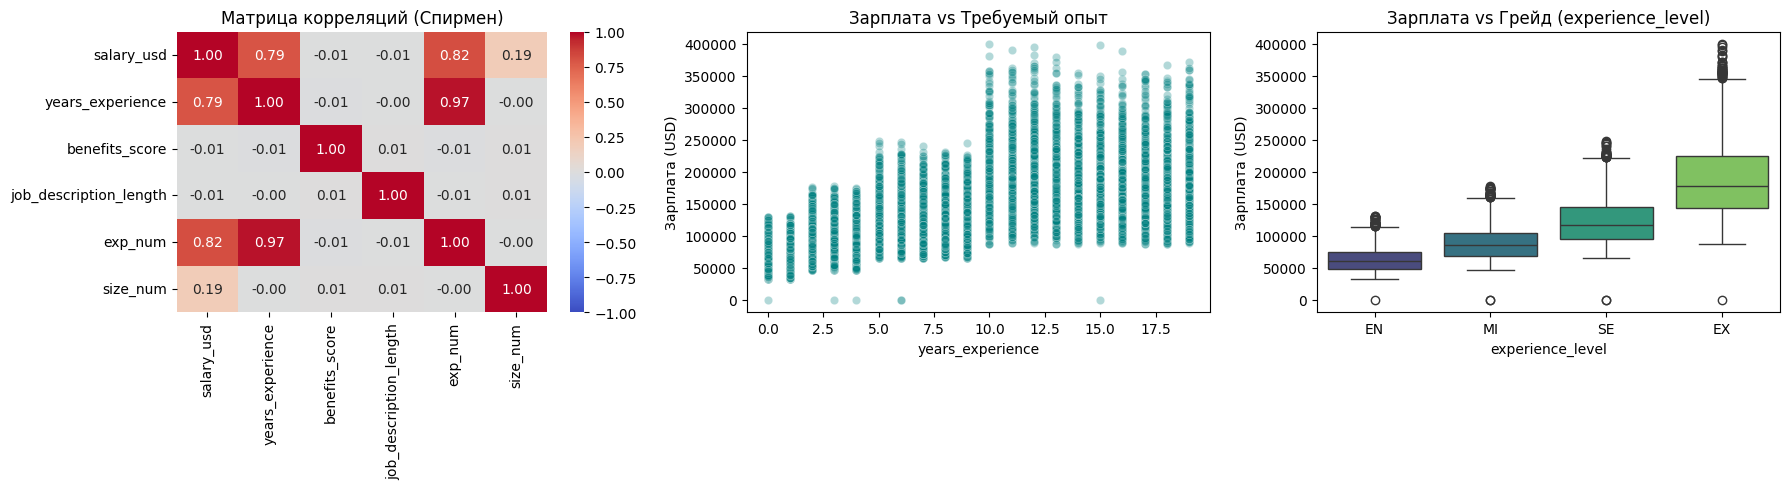

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# 1. Подготовка данных - фильтруем аномалии ТОЛЬКО для EDA
df_eda = df[(df['salary_usd'] > 0) & (df['salary_usd'] < 500000) & 
            (df['benefits_score'] <= 10)].copy()

# Для корреляции Спирмена переведем порядковые категории в числа
level_map = {'EN': 0, 'MI': 1, 'SE': 2, 'EX': 3}
size_map = {'S': 0, 'M': 1, 'L': 2}
df_eda['exp_num'] = df_eda['experience_level'].map(level_map)
df_eda['size_num'] = df_eda['company_size'].map(size_map)

cols_for_corr = ['salary_usd', 'years_experience', 'benefits_score', 
                 'job_description_length', 'exp_num', 'size_num']

# 2. Расчет корреляций Спирмена и p-value
print("--- Статистическая значимость корреляций с salary_usd (Спирмен) ---")
for col in cols_for_corr[1:]:
    corr, p_val = stats.spearmanr(df_eda['salary_usd'], df_eda[col], nan_policy='omit')
    significance = "Значима (p < 0.05)" if p_val < 0.05 else "НЕ значима"
    print(f"{col}: r = {corr:.3f} | p-value = {p_val:.3e} | {significance}")

# 3. Визуализация
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Хитмап
corr_matrix = df_eda[cols_for_corr].corr(method='spearman')
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('Матрица корреляций (Спирмен)')

# Диаграмма рассеяния (Scatter plot)
sns.scatterplot(data=df_eda, x='years_experience', y='salary_usd', alpha=0.3, ax=axes[1], color='teal')
axes[1].set_title('Зарплата vs Требуемый опыт')
axes[1].set_ylabel('Зарплата (USD)')

# Боксплот по категориям
sns.boxplot(data=df_eda, x='experience_level', y='salary_usd', order=['EN', 'MI', 'SE', 'EX'], ax=axes[2], palette='viridis')
axes[2].set_title('Зарплата vs Грейд (experience_level)')
axes[2].set_ylabel('Зарплата (USD)')

plt.tight_layout()
plt.show()

### Значимость всех пар на тепловой карте

Проверим все 15 пар шести признаков. Для каждой пары покажем коэффициент Спирмена, число наблюдений и p-value. Используем ту же выборку `df_eda`, что и на графиках выше. Пропуски удаляются отдельно в каждой паре.

Нулевая гипотеза: ранговая корреляция равна нулю. Альтернатива двусторонняя. Уровень значимости равен 0,05. Поправка Холма учитывает 15 одновременных проверок. Расчёт p-value предполагает независимость строк. Вакансии одной компании могут быть зависимы, поэтому выводы относятся к учебному файлу.

In [8]:
from IPython.display import display

pair_rows = []
for i, left in enumerate(cols_for_corr):
    for right in cols_for_corr[i + 1:]:
        observed = df_eda[[left, right]].dropna()
        rho, p = stats.spearmanr(observed[left], observed[right])
        pair_rows.append({'Признак 1': left, 'Признак 2': right,
                          'n': len(observed), 'ρ Спирмена': rho, 'p': p})
pair_results = pd.DataFrame(pair_rows)
pair_pvalues = pair_results['p'].to_numpy()
pair_order = np.argsort(pair_pvalues)
pair_adjusted = np.empty_like(pair_pvalues)
pair_adjusted[pair_order] = np.minimum(1, np.maximum.accumulate(
    (len(pair_pvalues) - np.arange(len(pair_pvalues))) * pair_pvalues[pair_order]))
pair_results['p с поправкой Холма'] = pair_adjusted
pair_results['p Holm < 0.05'] = pair_adjusted < 0.05
assert len(pair_results) == 15
format_pair_p = lambda p: '<1e-300' if p < 1e-300 else f'{p:.3g}'
display(pair_results.style.format({'ρ Спирмена': '{:.3f}', 'p': format_pair_p,
                                   'p с поправкой Холма': format_pair_p}))

,Признак 1,Признак 2,n,ρ Спирмена,p,p с поправкой Холма,p Holm < 0.05
0,salary_usd,years_experience,14965,0.791,<1e-300,<1e-300,True
1,salary_usd,benefits_score,14965,-0.005,0.511,1,False
2,salary_usd,job_description_length,14957,-0.006,0.444,1,False
3,salary_usd,exp_num,14965,0.815,<1e-300,<1e-300,True
4,salary_usd,size_num,14965,0.193,4.44e-126,5.33e-125,True
5,years_experience,benefits_score,14965,-0.008,0.307,1,False
6,years_experience,job_description_length,14957,-0.005,0.545,1,False
7,years_experience,exp_num,14965,0.971,<1e-300,<1e-300,True
8,years_experience,size_num,14965,-0.004,0.586,1,False
9,benefits_score,job_description_length,14957,0.007,0.407,1,False


**Результаты.** Связи зарплаты со стажем, грейдом и размером компании значимы при p < 0,05.
Ранговая корреляция с грейдом составляет около 0,82, со стажем около 0,79. Обе связи сильные и положительные.
Связь с размером компании положительная, но очень слабая: около 0,19.

У балла соцпакета и длины описания коэффициенты близки к нулю, p-value выше 0,05.
Значимой монотонной связи с зарплатой не обнаружено. Это не доказывает отсутствия любой связи.

На диаграмме рассеяния виден ступенчатый рост зарплат со стажем.
При стаже больше 10 лет разброс увеличивается: значения лежат примерно от 100 до 400 тыс. USD.
На ящичных диаграммах медианная зарплата растёт при переходе от EN к MI, SE и EX.
У EX самый широкий межквартильный размах.

Стаж и грейд очень сильно связаны между собой: коэффициент около 0,97.
Они во многом отражают одну характеристику вакансии.


--- Таблица сопряженности: Уровень опыта vs Размер компании (в %) ---


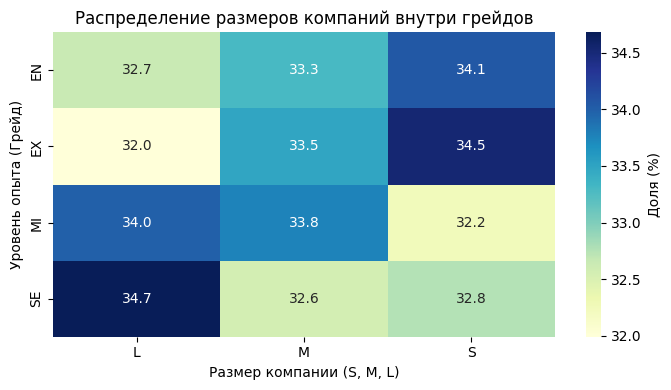

In [9]:
print("--- Таблица сопряженности: Уровень опыта vs Размер компании (в %) ---")
# Строим таблицу и нормализуем по строкам - видеть распределение внутри каждого грейда
crosstab_data = pd.crosstab(df_eda['experience_level'], df_eda['company_size'], normalize='index') * 100

plt.figure(figsize=(7, 4))
sns.heatmap(crosstab_data, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'Доля (%)'})
plt.title('Распределение размеров компаний внутри грейдов')
plt.ylabel('Уровень опыта (Грейд)')
plt.xlabel('Размер компании (S, M, L)')
plt.tight_layout()
plt.show()

### 3.2. Таблицы сопряжённости и гипотезы

В таблице `experience_level` и `company_size` доли малых, средних и крупных компаний близки для всех уровней опыта.
Равномерность может быть связана со способом формирования учебной выборки.
Она не доказывает синтетическое происхождение данных или независимость признаков.

Сильная связь стажа и грейда может делать отдельные коэффициенты линейной модели нестабильными.
Это не запрещает использовать линейные модели. Можно сравнить регуляризацию, удаление одного признака и PCA.
Бинаризация грейда в `is_senior_or_above` тоже возможна, но сама по себе не гарантирует решения проблемы.

Отношение зарплаты к средней зарплате грейда может помочь описать уже известные зарплаты.
Использовать его для прогноза той же зарплаты нельзя: формула содержит целевое значение и создаёт утечку.
Слабые парные связи балла соцпакета и длины описания также не дают основания сразу исключать их из будущей модели.

Для дальнейшей проверки сформулируем две гипотезы:
1. Грейд и стаж могут частично заменять друг друга при прогнозе зарплаты. Разница парных корреляций сама по себе не показывает, какой признак полезнее в модели.
2. PCA может сжать эту связанную пару в одну компоненту. Сохранённая дисперсия и качество прогноза требуют отдельной проверки.

В пункте 5 проверим PCA и создадим новые признаки без использования зарплаты.


**4. Предобработка данных**

Необходимо подготовить данные к дальнейшему анализу и моделированию:

- преобразуйте форматы данных при необходимости;
- если в данных присутствуют пропущенные значения, примите решение о способе их обработки (удалить строки/столбцы или заполнить значениями); обоснуйте выбранный подход и реализуйте его;
- выявите выбросы, примите решение об их корректировке или удалении и реализуйте их;
- осуществите разные виды масштабирования и трансформации не менее двух числовых признаков, прокомментируйте полученные результаты;
- осуществите трансформацию категориального признака, выберите и обоснуйте используемый подход, прокомментируйте полученные результаты. 

Важно не только выполнить техническую обработку, но и дать содержательные комментарии по каждому шагу.

### 4.1. План обработки и рабочая копия

Продолжим анализ из пунктов 1–3. Целевая переменная: `salary_usd`.

План работы:
1. Преобразовать даты и привести варианты названий к единым категориям.
2. Обработать ошибки и подозрительные значения. Записать изменения в журнал.
3. Разделить данные на обучающую и отложенную части. Затем заполнить пропуски в признаках.
4. Сравнить три способа масштабирования и два нелинейных преобразования для двух числовых признаков.
5. Закодировать категории. В пункте 5 создать шесть признаков, проверить их связь с зарплатой и изучить PCA.

Используем методы из лекций: лекция 1, слайды 45–59 (разбиение и утечки); лекция 2, слайды 47–53
(корреляции); лекция 3, слайды 7–18, 26–45 (очистка, масштабирование и кодирование);
лекция 4, слайды 8–30 (PCA). PDF доступны в [папке курса](https://disk.360.yandex.ru/d/k903xBTIzxMmVQ).

Для запуска положите `ai_job_dataset_upd.csv` рядом с ноутбуком. Зависимости указаны в `requirements.txt`.
Выполняйте ячейки по порядку, начиная с первого пункта.


In [10]:
from pathlib import Path
from itertools import combinations
import hashlib
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import scipy
from scipy import stats
import sklearn
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, OrdinalEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from IPython.display import display

RANDOM_STATE = 42
ALPHA = 0.05
LEVELS = ['EN', 'MI', 'SE', 'EX']
SIZES = ['S', 'M', 'L']
LEVEL_MAP = dict(zip(LEVELS, range(4)))
SIZE_MAP = dict(zip(SIZES, range(3)))
BLUE, GOLD, GRAY = '#31688e', '#b98524', '#68727a'
sns.set_theme(style='whitegrid', font='DejaVu Sans', font_scale=1.02)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
pd.set_option('display.max_columns', 12)
pd.set_option('display.max_rows', 25)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
report = {}  # Числа и пояснения для сверки выводов при воспроизведении.

def holm(pvalues):
    """Поправка Холма: контроль семейной вероятности ошибки I рода."""
    p = np.asarray(pvalues, dtype=float)
    order = np.argsort(p)
    adjusted = np.minimum(1, np.maximum.accumulate((len(p)-np.arange(len(p))) * p[order]))
    result = np.empty_like(p)
    result[order] = adjusted
    return result

def p_text(p):
    return '<1e-300' if p < 1e-300 else f'{p:.3g}'

def show_stats(table, pcols=()):
    formats = {c: p_text for c in pcols}
    display(table.style.format(formats, precision=3, thousands=' '))

def finish():
    plt.tight_layout()
    plt.show()

display(pd.Series({'Python': platform.python_version(), 'pandas': pd.__version__,
                   'NumPy': np.__version__, 'SciPy': scipy.__version__,
                   'scikit-learn': sklearn.__version__, 'seaborn': sns.__version__}, name='Версия'))


def ru_number(value, decimals=0):
    return f'{value:,.{decimals}f}'.replace(',', ' ').replace('.', ',')


def ru_rows(n):
    if 11 <= n % 100 <= 14:
        word = 'строк'
    elif n % 10 == 1:
        word = 'строка'
    elif n % 10 in (2, 3, 4):
        word = 'строки'
    else:
        word = 'строк'
    return f'{ru_number(n)} {word}'


Python               3.11.5
pandas                2.2.1
NumPy                1.26.4
SciPy                1.11.4
scikit-learn    1.4.1.post1
seaborn              0.13.2
Name: Версия, dtype: object

In [11]:
raw = df.copy(deep=True)
DATA_PATH = Path('ai_job_dataset_upd.csv')
source_sha256 = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()
assert raw.equals(pd.read_csv(DATA_PATH, sep=';'))
print('Рабочая копия:', raw.shape)
print('Полные дубликаты:', raw.duplicated().sum(), '; повторы job_id:', raw.job_id.duplicated().sum())

Рабочая копия: (15000, 19)
Полные дубликаты: 0 ; повторы job_id: 0


**Правила очистки.** Дубликатов нет. Удаляем пробелы по краям строк. Заменяем US и UK полными названиями стран.
Приводим варианты написания отраслей к единым категориям. Считаем `Ph` сокращением от `PhD`.
Эти исправления опираются на имеющийся словарь. Смысл кодов `8888`, `9999` и `6` неизвестен, поэтому заменяем их пропусками.

Для зарплат принимаем рабочий диапазон **100 ≤ salary_usd < 500 000**.
Нулевую и отрицательную годовую оплату в этой задаче не используем.
Значения 1, 3, 5, 10, 12 и 45 USD тоже считаем сомнительными: следующая годовая зарплата равна 32 519 USD.
Порог 100 USD служит правилом поиска аномалий в этом файле. Он не задаёт универсальную нижнюю границу зарплаты.
Три очень высокие зарплаты считаем сомнительными. Подтверждения ошибки у нас нет.
Между обычным максимумом 399 095 USD и следующим значением 9 383 302 USD есть большой разрыв.
Ниже проверим, как выбранный порог влияет на результат. Значения за усами ящичной диаграммы сами по себе не удаляем.

Допустимый балл соцпакета по словарю составляет от 1 до 10.
Для длины описания принимаем рабочий диапазон от 10 до 1 000 000 символов.
Отрицательная длина невозможна. Описание из 0, 1 или 6 символов выглядит сомнительно.
Многомиллионные значения сильно отличаются от остальных. Восстановить правильные значения нельзя, поэтому ставим `NaN`.
Исходный `df` сохраняем. Все изменения рабочей копии записываем в журнал.


In [12]:
SALARY_MIN = 100
SALARY_CAP = 500_000  # Допущение для основного анализа, не универсальный предел оплаты.
checked = raw.copy(deep=True)
changes = []

def record_replace(column, new_values, reason):
    old = checked[column].copy()
    changed = ~((old == new_values) | (old.isna() & new_values.isna()))
    for idx in checked.index[changed.fillna(True)]:
        changes.append({'job_id': checked.at[idx,'job_id'], 'column':column,
                        'before': str(old.at[idx]), 'after': str(new_values.at[idx]), 'reason':reason})
    checked[column] = new_values

for col in checked.select_dtypes('object'):
    record_replace(col, checked[col].str.strip(), 'Пробелы по краям строки')
aliases = {
    'employee_residence': {'US':'United States', 'UK':'United Kingdom', '8888':np.nan},
    'education_required': {'Associate.':'Associate', 'Ph':'PhD', '6':np.nan},
    'industry': {'Retail_':'Retail', 'manufacturing':'Manufacturing', 'Transport':'Transportation',
                 'Governmnt':'Government', 'Telecom':'Telecommunications', '9999':np.nan}
}
for col,mapping in aliases.items():
    record_replace(col, checked[col].replace(mapping), 'Явный словарь исправлений')

for col in ['posting_date','application_deadline']:
    checked[col] = pd.to_datetime(checked[col], format='%Y-%m-%d', errors='coerce')

numeric_invalid = {
    'salary_usd': (checked.salary_usd < SALARY_MIN) | (checked.salary_usd >= SALARY_CAP),
    'benefits_score': checked.benefits_score.notna() & ~checked.benefits_score.between(1,10),
    'job_description_length': checked.job_description_length.notna() & ~checked.job_description_length.between(10,1_000_000)
}
for col,mask in numeric_invalid.items():
    record_replace(col, checked[col].mask(mask), 'Недопустимо или подозрительно по объявленному правилу')

audit = pd.DataFrame(changes)
display(audit.groupby(['column','reason']).size().rename('Изменений').to_frame())
display(audit[audit.column.isin(numeric_invalid)][['job_id','column','before','after']])
assert checked.job_id.is_unique
assert checked.experience_level.isin(LEVELS).all()
assert checked.company_size.isin(SIZES).all()
assert checked.remote_ratio.isin([0,50,100]).all()
assert checked.education_required.dropna().isin(['Associate','Bachelor','Master','PhD']).all()
assert checked.years_experience.between(0,60).all()
assert (checked.application_deadline >= checked.posting_date).all()
salary_valid = checked.salary_usd.dropna()


Изменений
column                 reason                                                       
benefits_score         Недопустимо или подозрительно по объявленному п...          1
education_required     Пробелы по краям строки                                     1
                       Явный словарь исправлений                                   3
employee_residence     Пробелы по краям строки                                     1
                       Явный словарь исправлений                                   3
industry               Пробелы по краям строки                                     2
                       Явный словарь исправлений                                   6
job_description_length Недопустимо или подозрительно по объявленному п...          6
salary_usd             Недопустимо или подозрительно по объявленному п...         14

,job_id,column,before,after
16,AI00123,salary_usd,10.0,nan
17,AI00192,salary_usd,-78.0,nan
18,AI00258,salary_usd,99999999.0,nan
19,AI00638,salary_usd,3.0,nan
20,AI00703,salary_usd,5.0,nan
21,AI00795,salary_usd,-999.0,nan
22,AI00947,salary_usd,10000000.0,nan
23,AI01451,salary_usd,45.0,nan
24,AI01856,salary_usd,12.0,nan
25,AI02040,salary_usd,-1.0,nan


In [13]:
display(pd.DataFrame({'До обработки':raw.isna().sum(),'После проверки':checked.isna().sum()}).loc[lambda t:t.sum(axis=1)>0])
display(audit.loc[audit.column.isin(['employee_residence','education_required','industry'])])
date_summary=pd.DataFrame({c:[checked[c].min(),checked[c].max(),checked[c].isna().sum()]
    for c in ['posting_date','application_deadline']},index=['Минимум','Максимум','Пропуски'])
display(date_summary)
print('Дедлайн раньше публикации:',(checked.application_deadline<checked.posting_date).sum())
report['clean_counts'] = (
    f'После проверки достоверная зарплата известна для {ru_number(checked.salary_usd.notna().sum())} вакансий. '
    f'Неизвестная или сомнительная зарплата: {ru_rows(int(checked.salary_usd.isna().sum()))}. '
    f'Пропусков в балле соцпакета: {checked.benefits_score.isna().sum()}. '
    f'Пропусков в длине описания: {checked.job_description_length.isna().sum()}.')

,До обработки,После проверки
salary_usd,10,24
employee_residence,2,3
education_required,5,6
industry,3,4
job_description_length,8,14
benefits_score,16,17


,job_id,column,before,after,reason
0,AI10023,employee_residence,United States,United States,Пробелы по краям строки
1,AI05962,education_required,Associate.,Associate.,Пробелы по краям строки
2,AI00192,industry,Government,Government,Пробелы по краям строки
3,AI05867,industry,Retail,Retail,Пробелы по краям строки
4,AI10035,employee_residence,US,United States,Явный словарь исправлений
5,AI10120,employee_residence,UK,United Kingdom,Явный словарь исправлений
6,AI10262,employee_residence,8888,nan,Явный словарь исправлений
7,AI00097,education_required,6,nan,Явный словарь исправлений
8,AI05962,education_required,Associate.,Associate,Явный словарь исправлений
9,AI06006,education_required,Ph,PhD,Явный словарь исправлений


,posting_date,application_deadline
Минимум,2024-01-01 00:00:00,2024-01-16 00:00:00
Максимум,2025-04-30 00:00:00,2025-07-11 00:00:00
Пропуски,0,0


Дедлайн раньше публикации: 0


После проверки достоверная зарплата известна для 14 976 вакансий. Неизвестная или сомнительная зарплата: 24 строки. Пропусков в балле соцпакета: 17. Пропусков в длине описания: 14.

Даты преобразованы успешно. Срок подачи заявок нигде не заканчивается раньше публикации.
В файле есть вакансии за 2024 год и январь–апрель 2025 года. Используем весь выданный файл.
По нему нельзя оценить весь рынок за 2025 год.
После исправлений US и United States относятся к одной стране. Аналогично объединены другие варианты категорий.

### 4.2. Проверка порога зарплат
Сравним несколько нижних и верхних порогов. Отдельно сохраним все положительные зарплаты.
Посмотрим, как меняются статистики. Качество прогноза здесь не оценивается.


In [14]:
sensitivity_rows = []
variants = [
    ('Все положительные', 0, np.inf),
    ('Только верхний порог 500 тыс.', 0, 500_000),
    ('От 100 до 500 тыс.', 100, 500_000),
    ('От 1 тыс. до 500 тыс.', 1_000, 500_000),
    ('От 10 тыс. до 500 тыс.', 10_000, 500_000),
    ('От 100 до 1 млн', 100, 1_000_000),
    ('От 100 до 5 млн', 100, 5_000_000),
]
for name, lower, upper in variants:
    part = raw.loc[(raw.salary_usd > 0) & (raw.salary_usd >= lower) & (raw.salary_usd < upper)]
    sensitivity_rows.append({'Вариант': name, 'n': len(part),
        'Среднее USD': part.salary_usd.mean(), 'Медиана USD': part.salary_usd.median(),
        'ρ зарплаты и стажа': stats.spearmanr(part.salary_usd, part.years_experience).statistic})
sensitivity = pd.DataFrame(sensitivity_rows).set_index('Вариант')
display(sensitivity)
selected = sensitivity.loc['От 100 до 500 тыс.']
report['salary_sensitivity'] = (
    f'При сохранении всех положительных зарплат среднее равно {ru_number(sensitivity.iloc[0]["Среднее USD"])} USD. '
    f'При рабочем диапазоне оно равно {ru_number(selected["Среднее USD"])} USD. '
    f'Медиана после обработки составляет {ru_number(selected["Медиана USD"], 1)} USD. '
    f'Связь зарплаты со стажем почти не меняется: ρ = {ru_number(selected["ρ зарплаты и стажа"], 3)}.')

,n,Среднее USD,Медиана USD,ρ зарплаты и стажа
Вариант,,,,
Все положительные,14985,"123,248.049","99,642.000",0.791
Только верхний порог 500 тыс.,14982,"115,304.279","99,622.000",0.792
От 100 до 500 тыс.,14976,"115,350.470","99,658.500",0.792
От 1 тыс. до 500 тыс.,14976,"115,350.470","99,658.500",0.792
От 10 тыс. до 500 тыс.,14976,"115,350.470","99,658.500",0.792
От 100 до 1 млн,14976,"115,350.470","99,658.500",0.792
От 100 до 5 млн,14976,"115,350.470","99,658.500",0.792


При сохранении всех положительных зарплат среднее равно 123 248 USD. При рабочем диапазоне оно равно 115 350 USD. Медиана после обработки составляет 99 658,5 USD. Связь зарплаты со стажем почти не меняется: ρ = 0,792.

Нижние пороги 100, 1 000 и 10 000 USD оставляют одинаковый набор строк.
Верхние пороги 500 тыс., 1 млн и 5 млн USD также дают одинаковый результат.
Значит, точный выбор порога внутри этого разрыва не влияет на результат.
Три экстремальные зарплаты заметно меняют среднее. Медиана и ранговая корреляция устойчивее.
Исключение этих строк остаётся нашим допущением. Если появится доступ к первоисточнику, значения нужно проверить.

### 4.3. Пропуски и разделение данных
В `benefits_score` и `job_description_length` заполняем пропуски медианами обучающей части.
Добавляем индикаторы, которые показывают, где значение отсутствовало.
Для пропусков в категориях используем `Unknown`. Так запись не получает произвольно выбранную страну, отрасль или образование.

**Пропуски в `salary_usd` не заполняем.** Иначе при обучении модель получила бы придуманный правильный ответ.
Строки без достоверной зарплаты сохраняем отдельно. Позже для них можно будет получить прогноз.
При расчёте корреляций используем только пары с известными значениями.

До обучения преобразований делим данные по названиям компаний.
В отложенную часть попадают 20% из 16 названий с округлением вверх: четыре компании.
Это около 25% строк. Названия компаний между частями не пересекаются.
Названия могут быть условными, поэтому независимость работодателей не гарантирована.
Разбиение позволяет проверить применение преобразований к новым данным.
Для независимой оценки качества модели оно не подходит: предыдущий анализ уже использовал весь файл.


На слайде 45 лекции 3 есть правило: «обучаем (fit) все шаги предобработки только на train».
Поэтому мы считаем медианы и параметры масштабирования на обучающей части, а к отложенной применяем уже готовые преобразования.
Здесь держим себя в руках: в test за подсказками не заглядываем.


In [15]:
usable=checked.loc[checked.salary_usd.notna()].copy()
unlabeled=checked.loc[checked.salary_usd.isna()].copy()
splitter=GroupShuffleSplit(n_splits=1,test_size=.2,random_state=RANDOM_STATE)
train_pos,test_pos=next(splitter.split(usable,groups=usable.company_name))
train=usable.iloc[train_pos].copy()
test=usable.iloc[test_pos].copy()
assert not set(train.company_name)&set(test.company_name)
assert not set(train.job_id)&set(test.job_id)
assert len(train)+len(test)+len(unlabeled)==len(raw)
display(pd.DataFrame({'Строки':[len(raw),len(usable),len(unlabeled),len(train),len(test)],
                       'Описание':['Исходник','Наблюдаемая цель','Неизвестная цель','Обучающая часть','Отложенная часть']}))
display(pd.DataFrame({'До проверок':raw.isna().sum(),'После проверок':checked.isna().sum()}).loc[lambda t:t.sum(axis=1)>0])

report['split'] = (
    f'Обучающая часть: {ru_rows(len(train))}, число компаний: {train.company_name.nunique()}. '
    f'Отложенная часть: {ru_rows(len(test))}, число компаний: {test.company_name.nunique()}. '
    f'Без достоверной зарплаты: {ru_rows(len(unlabeled))}. Они сохранены отдельно. '
    f'Пересечений job_id и названий компаний нет.')

,Строки,Описание
0,15000,Исходник
1,14976,Наблюдаемая цель
2,24,Неизвестная цель
3,11195,Обучающая часть
4,3781,Отложенная часть


,До проверок,После проверок
salary_usd,10,24
employee_residence,2,3
education_required,5,6
industry,3,4
job_description_length,8,14
benefits_score,16,17


Обучающая часть: 11 195 строк, число компаний: 12. Отложенная часть: 3 781 строка, число компаний: 4. Без достоверной зарплаты: 24 строки. Они сохранены отдельно. Пересечений job_id и названий компаний нет.

Медиана устойчива к крайним значениям, но заполнение пропусков уменьшает разброс.
Истинные значения при этом остаются неизвестными.
Поэтому заполненные данные используем для подготовки матрицы, а связи изучаем по исходно известным парам.
Даже редкие пропуски могут возникать закономерно. Их индикаторы сохраняют эту информацию для модели.


### 4.4. Масштабирование двух числовых признаков
Для `years_experience` и `job_description_length` сравним MinMaxScaler, StandardScaler и RobustScaler.
В каждом `Pipeline` сначала заполняем пропуски медианой, затем меняем масштаб.
Параметры определяем только по обучающей части.
Все три преобразования линейны. Они меняют шкалу, но **не делают распределение нормальным**.
Зарплату в матрицу признаков не включаем.


,Метод,Часть,Признак,Среднее,SD (ddof=0),Медиана,IQR,min,max
0,Min-Max,train,years_experience,0.333,0.292,0.263,0.421,0.000,1.000
1,Min-Max,test,years_experience,0.317,0.290,0.211,0.421,0.000,1.000
2,Min-Max,train,job_description_length,0.503,0.288,0.506,0.498,0.000,1.000
3,Min-Max,test,job_description_length,0.499,0.289,0.506,0.498,0.000,1.000
4,Standard,train,years_experience,0.000,1.000,-0.239,1.440,-1.139,2.280
5,Standard,test,years_experience,-0.055,0.991,-0.419,1.440,-1.139,2.280
6,Standard,train,job_description_length,-0.000,1.000,0.012,1.730,-1.746,1.727
7,Standard,test,job_description_length,-0.012,1.002,0.010,1.729,-1.746,1.727
8,Robust,train,years_experience,0.166,0.695,0.000,1.000,-0.625,1.750
9,Robust,test,years_experience,0.128,0.688,-0.125,1.000,-0.625,1.750


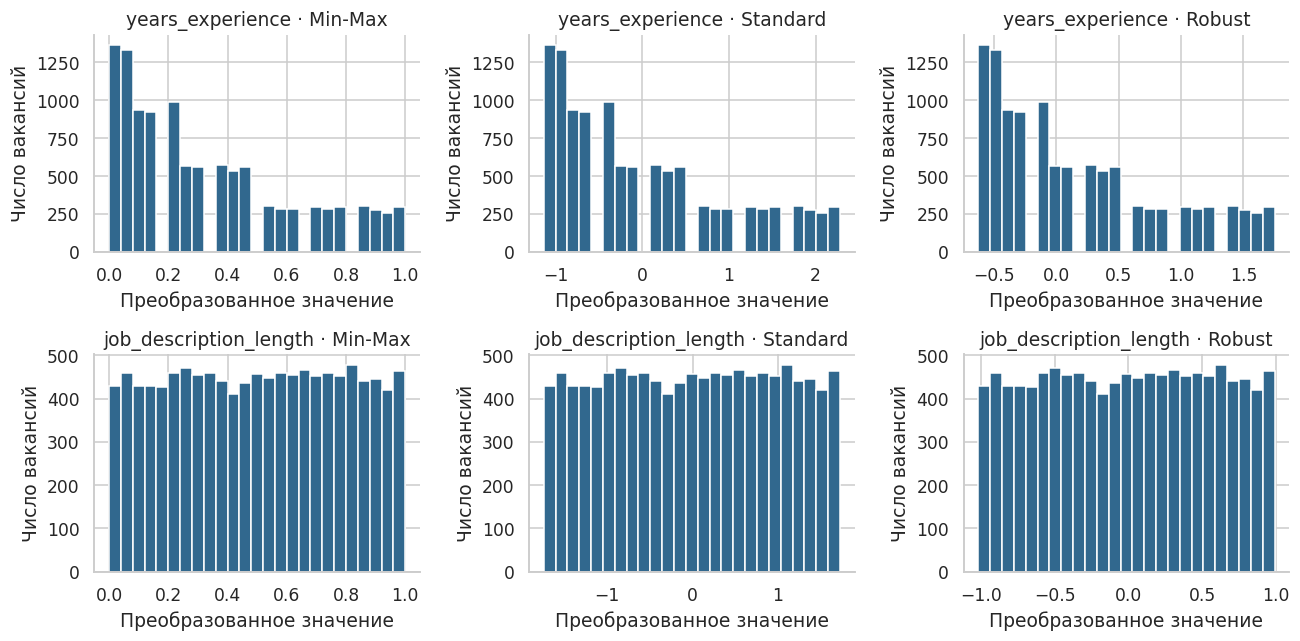

In [16]:
scale_columns=['years_experience','job_description_length']
scalers={'Min-Max':MinMaxScaler(),'Standard':StandardScaler(),'Robust':RobustScaler()}
scaled_train,scaled_test={},{}
scale_pipelines={}
scale_rows=[]
for name,scaler in scalers.items():
    pipe=Pipeline([('imputer',SimpleImputer(strategy='median')),('scaler',scaler)])
    a=pipe.fit_transform(train[scale_columns]); b=pipe.transform(test[scale_columns])
    scaled_train[name]=pd.DataFrame(a,index=train.index,columns=scale_columns)
    scaled_test[name]=pd.DataFrame(b,index=test.index,columns=scale_columns)
    scale_pipelines[name]=pipe
    for col in scale_columns:
        for split,data in [('train',scaled_train[name]),('test',scaled_test[name])]:
            x=data[col]
            scale_rows.append({'Метод':name,'Часть':split,'Признак':col,'Среднее':x.mean(),
                'SD (ddof=0)':x.std(ddof=0),'Медиана':x.median(),'IQR':x.quantile(.75)-x.quantile(.25),
                'min':x.min(),'max':x.max()})
scale_summary=pd.DataFrame(scale_rows)
display(scale_summary)
assert np.allclose(scaled_train['Standard'].mean(),0,atol=1e-10)
assert np.allclose(scaled_train['Standard'].std(ddof=0),1,atol=1e-10)
assert np.allclose(scaled_train['Min-Max'].min(),0)
assert np.allclose(scaled_train['Min-Max'].max(),1)
assert np.allclose(scaled_train['Robust'].median(),0)
fig,axes=plt.subplots(2,3,figsize=(12,6))
for row,col in enumerate(scale_columns):
    for ax,(name,frame) in zip(axes[row],scaled_train.items()):
        ax.hist(frame[col],bins=25,color=BLUE)
        ax.set(title=f'{col} · {name}',xlabel='Преобразованное значение',ylabel='Число вакансий')
finish()

На обучающей части MinMaxScaler даёт диапазон от 0 до 1.
После StandardScaler среднее равно 0, стандартное отклонение равно 1.
После RobustScaler медиана равна 0, межквартильный размах равен 1.

В отложенной части эти свойства могут не сохраняться.
Если новое значение выходит за обучающий диапазон, MinMaxScaler может дать число меньше 0 или больше 1.
Форма гистограмм при линейных преобразованиях сохраняется.

Для PCA ниже используем StandardScaler. Так длина описания не будет преобладать из-за больших численных значений.
RobustScaler полезен, если допустимые крайние значения сохранены. Ошибки в данных всё равно нужно обрабатывать отдельно.


### 4.5. Нелинейные преобразования: log1p и квадратный корень
Для тех же двух признаков сравним исходную шкалу, `log1p(x)` и `sqrt(x)`.
Все значения неотрицательны. Рассчитаем асимметрию и эксцесс.
У этих преобразований нет подбираемых параметров. Медианы для заполнения пропусков уже получены на обучающей части.
Уменьшение асимметрии само по себе не гарантирует улучшения прогноза.


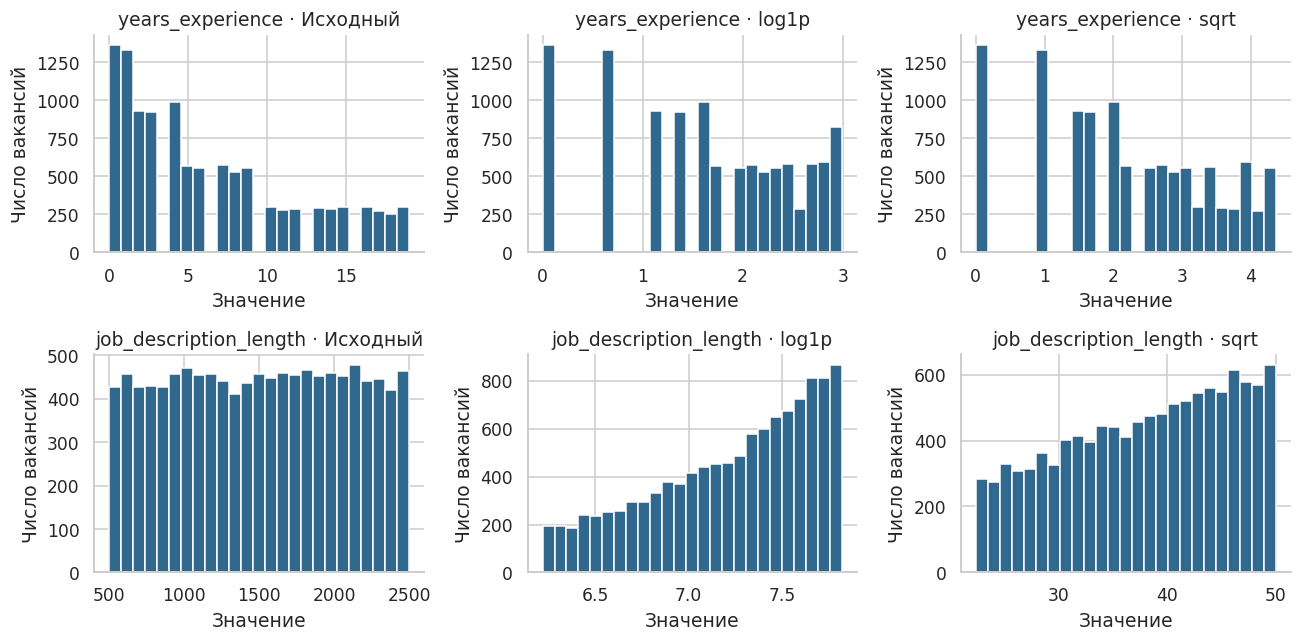

Асимметрия  Эксцесс
Признак                Метод                        
years_experience       Исходный       0.761   -0.556
                       log1p         -0.364   -0.921
                       sqrt          -0.112   -0.863
job_description_length Исходный      -0.014   -1.197
                       log1p         -0.566   -0.752
                       sqrt          -0.277   -1.072

In [17]:
imputed_train=scale_pipelines['Standard'].named_steps['imputer'].transform(train[scale_columns])
imputed_test=scale_pipelines['Standard'].named_steps['imputer'].transform(test[scale_columns])
transforms={'Исходный':lambda x:x,'log1p':np.log1p,'sqrt':np.sqrt}
transform_rows=[]
fig,axes=plt.subplots(2,3,figsize=(12,6))
for j,col in enumerate(scale_columns):
    for ax,(name,func) in zip(axes[j],transforms.items()):
        v=func(imputed_train[:,j])
        transform_rows.append({'Признак':col,'Метод':name,'Асимметрия':stats.skew(v,bias=False),
                               'Эксцесс':stats.kurtosis(v,bias=False)})
        ax.hist(v,bins=25,color=BLUE)
        ax.set(title=f'{col} · {name}',xlabel='Значение',ylabel='Число вакансий')
finish()
transform_summary=pd.DataFrame(transform_rows).set_index(['Признак','Метод'])
display(transform_summary)
log_train,log_test=np.log1p(imputed_train),np.log1p(imputed_test)
assert np.isfinite(log_test).all()
report['transforms']='; '.join(f'{c}: исходная асимметрия {transform_summary.loc[(c,"Исходный"),"Асимметрия"]:.2f}, '
    f'log1p {transform_summary.loc[(c,"log1p"),"Асимметрия"]:.2f}, '
    f'sqrt {transform_summary.loc[(c,"sqrt"),"Асимметрия"]:.2f}' for c in scale_columns)+'.'

years_experience: исходная асимметрия 0.76, log1p -0.36, sqrt -0.11; job_description_length: исходная асимметрия -0.01, log1p -0.57, sqrt -0.28.

Для стажа оба преобразования уменьшают правую асимметрию.
Длина описания после очистки распределена примерно равномерно.
Логарифм создаёт отрицательную асимметрию. Поэтому автоматически применять его к длине описания не будем.
В основной матрице оставляем исходные числовые признаки и стандартизируем их.
Для нулевого стажа подходит log1p, поскольку обычный log(0) не определён.


### 4.6. Кодирование категорий
Сначала покажем порядковое кодирование: EN < MI < SE < EX и S < M < L.
Числовые коды сохраняют порядок. Равные расстояния между категориями из этого не следуют.

В основной матрице используем one-hot encoding (OHE), в том числе для грейда.
При таком кодировании линейная модель сможет оценить отдельный эффект каждой категории.
Образование тоже кодируем через OHE: категорию `Unknown` нельзя поставить на определённую ступень образования.

`job_id` и `company_name` в признаки не включаем. Название компании нужно только для разбиения данных.
Из навыков и дат создадим новые признаки в пункте 5.


In [18]:
ordinal=OrdinalEncoder(categories=[LEVELS,SIZES],handle_unknown='use_encoded_value',unknown_value=-1)
ordinal_train=ordinal.fit_transform(train[['experience_level','company_size']])
ordinal_test=ordinal.transform(test[['experience_level','company_size']])
display(pd.DataFrame({'Грейд':LEVELS,'Код':[0,1,2,3]}))
display(pd.DataFrame({'Размер':SIZES,'Код':[0,1,2]}))
remote_encoder=OneHotEncoder(sparse_output=False,handle_unknown='ignore',dtype=int)
remote_encoder.fit(train[['remote_ratio']])
display(pd.DataFrame(remote_encoder.transform(pd.DataFrame({'remote_ratio':[0,50,100]})),
    columns=remote_encoder.get_feature_names_out(),index=['Офис','Гибрид','Удалённо']))

base_numeric=['years_experience','benefits_score','job_description_length']
base_categorical=['experience_level','company_size','remote_ratio','education_required',
                  'industry','employee_residence','company_location','employment_type','job_title','salary_currency']
def make_preprocessor(numeric, categorical):
    return ColumnTransformer([
        ('numeric',Pipeline([('imputer',SimpleImputer(strategy='median',add_indicator=True)),
                             ('scaler',StandardScaler())]),numeric),
        ('category',Pipeline([('imputer',SimpleImputer(strategy='constant',fill_value='Unknown')),
                              ('encoder',OneHotEncoder(handle_unknown='ignore',sparse_output=False))]),categorical)
    ],remainder='drop',verbose_feature_names_out=True)

base_preprocessor=make_preprocessor(base_numeric,base_categorical)
X_train_base=base_preprocessor.fit_transform(train)
X_test_base=base_preprocessor.transform(test)
base_feature_names=base_preprocessor.get_feature_names_out()
assert np.isfinite(X_train_base).all() and np.isfinite(X_test_base).all()
assert X_train_base.shape[1]==X_test_base.shape[1]
assert not any('salary_usd' in c or 'job_id' in c or 'company_name' in c for c in base_feature_names)
print('Матрица train:',X_train_base.shape,'; отложенная:',X_test_base.shape)
display(pd.DataFrame(X_train_base[:5,:8],columns=base_feature_names[:8]))

,Грейд,Код
0,EN,0
1,MI,1
2,SE,2
3,EX,3


,Размер,Код
0,S,0
1,M,1
2,L,2


,remote_ratio_0,remote_ratio_50,remote_ratio_100
Офис,1,0,0
Гибрид,0,1,0
Удалённо,0,0,1


Матрица train: (11195, 104) ; отложенная: (3781, 104)


,numeric__years_experience,numeric__benefits_score,numeric__job_description_length,numeric__missingindicator_benefits_score,numeric__missingindicator_job_description_length,category__experience_level_EN,category__experience_level_EX,category__experience_level_MI
0,-0.959,-1.584,-0.412,-0.030,-0.028,1.000,0.000,0.000
1,-0.779,1.312,0.815,-0.030,-0.028,0.000,0.000,1.000
2,0.121,0.760,-0.278,-0.030,-0.028,0.000,0.000,0.000
3,0.121,-1.102,-1.192,-0.030,-0.028,0.000,0.000,0.000
4,-1.139,0.071,-0.381,-0.030,-0.028,1.000,0.000,0.000


При OHE формата работы у каждой строки ровно один активный столбец.
Модель не обязана считать, что переход от 0 к 50 влияет на зарплату так же, как переход от 50 к 100.

Список категорий определяется по обучающей части.
Благодаря `handle_unknown='ignore'` новая категория кодируется нулями во всём соответствующем блоке.
При дальнейшем использовании модели нужно следить за долей таких категорий.

В полной OHE-матрице есть линейные зависимости.
Для обычной линейной регрессии с константой можно убрать одну категорию через `drop='first'`.
В регуляризованной модели допустимо оставить все категории.
Числовые и категориальные признаки обработаны отдельно.
Матрицы имеют одинаковые столбцы и не содержат пропусков или бесконечных значений.


**5. Конструирование признаков**

Необходимо создать новые признаки на основе уже имеющихся данных, чтобы расширить информационное пространство и улучшить качество анализа или будущего моделирования. 

- разработайте не менее **трех** новых признаков, рассчитанных на основе существующих; 
- для каждого нового признака укажите, какую информацию он добавляет и почему его включение может быть полезным для анализа или моделирования;
- исследуйте как новые признаки взаимосвязаны с ранее определенной целевой переменной;
- опишите выявленные закономерности и оцените потенциальную ценность новых признаков для последующего моделирования.

### 5.1. Шесть новых признаков
Все признаки рассчитаны без использования зарплаты.
Предполагаем, что прогноз нужен для вакансии, поля которой уже известны.

| Признак | Расчёт | Возможная польза и ограничения |
|---|---|---|
| application_window_days | Разница между датой окончания приёма и датой публикации, в днях | Плановый срок приёма заявок. Фактический срок найма может отличаться. |
| skill_count | Число уникальных непустых навыков | Число перечисленных требований. Список может быть неполным. |
| cross_border | Страны компании и сотрудника различаются | Географическое несовпадение. Гражданство и факт переезда неизвестны. |
| has_cloud_tools | В списке есть AWS, Azure или GCP | Требование облачных технологий. Уровень владения ими неизвестен. |
| senior_large | Грейд SE или EX при размере компании L | Сочетание старшего грейда и крупной компании. |
| years_experience_sq | Квадрат требуемого стажа | Позволяет простой модели описать нелинейную связь со стажем. |

Если одна из стран неизвестна, `cross_border` остаётся `NaN`.
Иначе сравнение с `Unknown` могло бы ошибочно отметить различие стран.
Если страна сотрудника ещё неизвестна при публикации, этот признак нельзя использовать для прогноза в тот момент.
Срок приёма заявок тоже должен быть известен заранее.


In [19]:
new_columns=['application_window_days','skill_count','cross_border','has_cloud_tools','senior_large','years_experience_sq']
def create_features(frame):
    result=frame.copy()
    tokens=frame.required_skills.fillna('').map(lambda s: {x.strip().casefold() for x in s.split(',') if x.strip()})
    result['application_window_days']=(frame.application_deadline-frame.posting_date).dt.days
    result['skill_count']=tokens.map(len)
    countries_known=frame.company_location.notna() & frame.employee_residence.notna()
    result['cross_border']=np.where(countries_known,(frame.company_location!=frame.employee_residence).astype(float),np.nan)
    result['has_cloud_tools']=tokens.map(lambda s:int(bool(s & {'aws','azure','gcp'})))
    result['senior_large']=(frame.experience_level.isin(['SE','EX']) & frame.company_size.eq('L')).astype(int)
    result['years_experience_sq']=frame.years_experience**2
    return result

features=create_features(checked)
feature_eda=features.loc[features.salary_usd.notna()]
train_fe=create_features(train)
test_fe=create_features(test)
display(features[new_columns].describe().T)
display(features[new_columns].isna().rename_axis('index').sum().to_frame('Пропуски'))
skill_counts=features.skill_count.value_counts().sort_index()
display(skill_counts.rename('Вакансий'))
assert features.application_window_days.ge(0).all()
assert features.skill_count.between(3,5).all()
assert features.cross_border.dropna().isin([0,1]).all()
# Проверка отсутствия зависимости производных признаков от целевой переменной.
shuffled_target=checked.copy()
shuffled_target['salary_usd']=np.random.default_rng(RANDOM_STATE).permutation(checked.salary_usd)
pd.testing.assert_frame_equal(create_features(shuffled_target)[new_columns],features[new_columns])

,count,mean,std,min,25%,50%,75%,max
application_window_days,"15,000.000",43.546,17.325,14.000,29.000,44.000,59.000,74.000
skill_count,"15,000.000",3.993,0.816,3.000,3.000,4.000,5.000,5.000
cross_border,"14,997.000",0.284,0.451,0.000,0.000,0.000,1.000,1.000
has_cloud_tools,"15,000.000",0.388,0.487,0.000,0.000,0.000,1.000,1.000
senior_large,"15,000.000",0.167,0.373,0.000,0.000,0.000,0.000,1.000
years_experience_sq,"15,000.000",69.856,97.609,0.000,4.000,25.000,100.000,361.000


,Пропуски
application_window_days,0
skill_count,0
cross_border,3
has_cloud_tools,0
senior_large,0
years_experience_sq,0


skill_count
3    5050
4    5007
5    4943
Name: Вакансий, dtype: int64

Приём заявок длится от 14 до 74 дней. В `required_skills` указано от трёх до пяти навыков.
Значит, «Top 5» в словаре не означает, что в каждой строке ровно пять записей.
При подсчёте удаляем повторы внутри списка. Также учитываем различия в регистре и пробелах.

Квадрат стажа сохраняет порядок наблюдений.
Его ранговая связь с зарплатой не показывает, добавляет ли он пользу по сравнению с исходным стажем.
После перемешивания зарплаты все шесть признаков остались прежними. Это подтверждает, что расчёт не использует целевую переменную.


### 5.2. Связь новых признаков с зарплатой
Для числовых признаков с повторяющимися рангами используем коэффициент Кендалла τ-b.
Для бинарных признаков сравним распределения зарплаты тестом Манна–Уитни.
Также рассчитаем рангово-бисериальную корреляцию: `2U/(n₁n₀) − 1`.
Положительный знак означает, что при значении признака 1 зарплата чаще выше.
Без дополнительных условий о форме распределений этот тест нельзя трактовать как проверку равенства медиан.

Уровень значимости равен 0,05.
Для коэффициента Кендалла проверяем H₀: τ = 0.
Для теста Манна–Уитни H₀ означает одинаковые распределения зарплаты в двух группах.
Обе альтернативы двусторонние. Для шести тестов вместе применяем поправку Холма.
Коэффициенты разных типов напрямую не ранжируем по величине.
В каждом расчёте используем только пары с известными значениями.

Расчёт p-value предполагает независимость строк.
Вакансии одной компании могут быть связаны, а способ формирования файла неизвестен.
Это ограничивает перенос результатов на рынок в целом.
Отсутствие значимости не доказывает равенство распределений или независимость признаков.


,n,Метод / эффект,Эффект,p,"Δ медиан 1−0, USD",p Holm
Признак,,,,,,
application_window_days,14 976,Кендалл τ-b,0.004,0.46,nan,1
skill_count,14 976,Кендалл τ-b,-0.010,0.105,nan,0.42
cross_border,14 973,Манн-Уитни / r_rb,0.009,0.393,608.000,1
has_cloud_tools,14 976,Манн-Уитни / r_rb,-0.007,0.449,-1 300.000,1
senior_large,14 976,Манн-Уитни / r_rb,0.666,<1e-300,73 436.000,<1e-300
years_experience_sq,14 976,Кендалл τ-b,0.599,<1e-300,nan,<1e-300


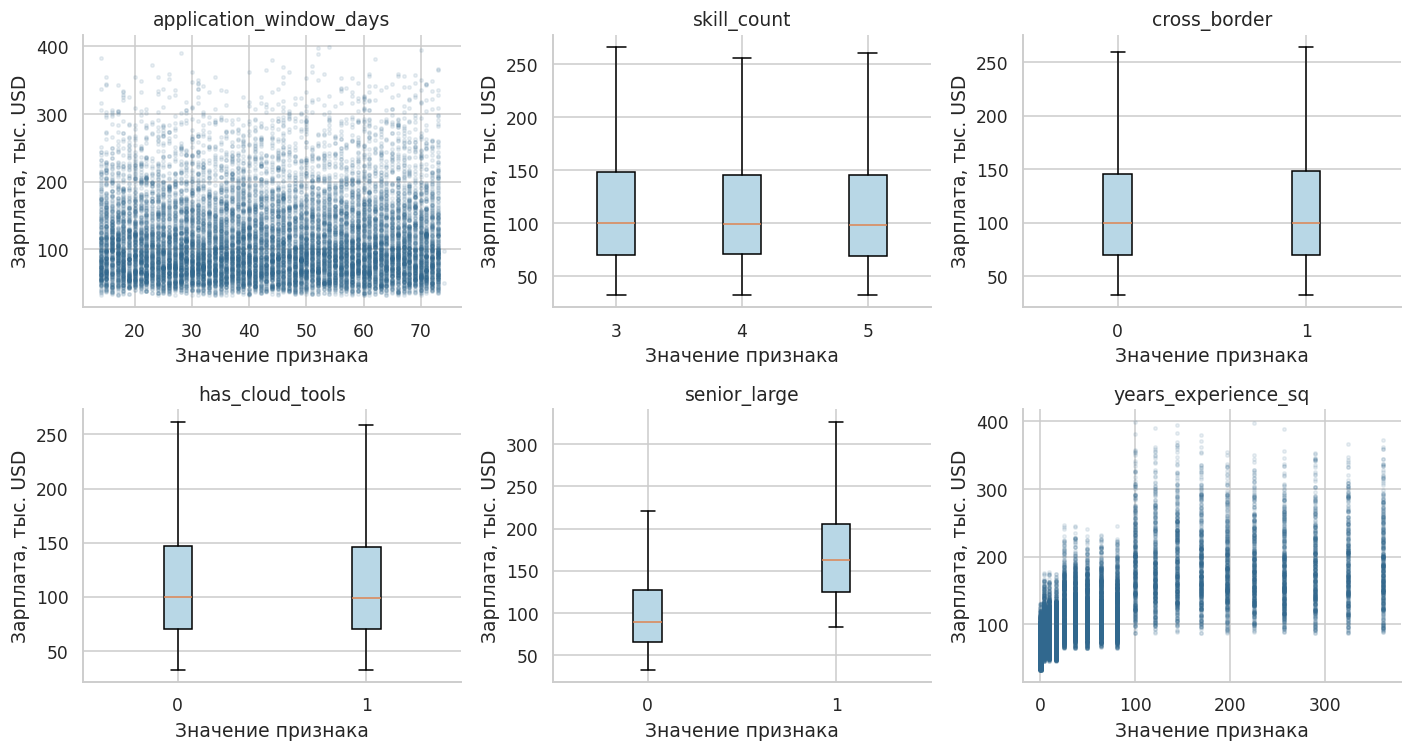

In [20]:
binary=['cross_border','has_cloud_tools','senior_large']
fe_rows=[]
for col in new_columns:
    pair=feature_eda[[col,'salary_usd']].dropna()
    if col in binary:
        one=pair.loc[pair[col]==1,'salary_usd']; zero=pair.loc[pair[col]==0,'salary_usd']
        u,p=stats.mannwhitneyu(one,zero,alternative='two-sided',method='asymptotic')
        effect=2*u/(len(one)*len(zero))-1
        method='Манн-Уитни / r_rb'
        delta=one.median()-zero.median()
    else:
        effect,p=stats.kendalltau(pair[col],pair.salary_usd)
        method='Кендалл τ-b'; delta=np.nan
    fe_rows.append({'Признак':col,'n':len(pair),'Метод / эффект':method,'Эффект':effect,
                    'p':p,'Δ медиан 1−0, USD':delta})
fe_associations=pd.DataFrame(fe_rows).set_index('Признак')
fe_associations['p Holm']=holm(fe_associations.p)
show_stats(fe_associations,['p','p Holm'])
fig,axes=plt.subplots(2,3,figsize=(13,7))
for ax,col in zip(axes.flat,new_columns):
    pair=feature_eda[[col,'salary_usd']].dropna()
    if col in binary or col=='skill_count':
        values=sorted(pair[col].unique())
        ax.boxplot([pair.loc[pair[col]==v,'salary_usd']/1000 for v in values],tick_labels=[str(int(v)) for v in values],
                   showfliers=False,patch_artist=True,boxprops={'facecolor':'#b8d7e6'})
    else:
        ax.scatter(pair[col],pair.salary_usd/1000,s=5,alpha=.1,color=BLUE,rasterized=True)
    ax.set(title=col,xlabel='Значение признака',ylabel='Зарплата, тыс. USD')
finish()
report['features']='\n'.join(f'- `{col}`: эффект {row["Эффект"]:.3f}, p Holm {p_text(row["p Holm"])}; '
    f'{"есть статистические основания отвергнуть H₀" if row["p Holm"]<ALPHA else "нет оснований отвергнуть H₀"}.'
    for col,row in fe_associations.iterrows())

- `application_window_days`: эффект 0.004, p Holm 1; нет оснований отвергнуть H₀.
- `skill_count`: эффект -0.010, p Holm 0.42; нет оснований отвергнуть H₀.
- `cross_border`: эффект 0.009, p Holm 1; нет оснований отвергнуть H₀.
- `has_cloud_tools`: эффект -0.007, p Holm 1; нет оснований отвергнуть H₀.
- `senior_large`: эффект 0.666, p Holm <1e-300; есть статистические основания отвергнуть H₀.
- `years_experience_sq`: эффект 0.599, p Holm <1e-300; есть статистические основания отвергнуть H₀.

На ящичных диаграммах скрыты маркеры за усами. Сами наблюдения остаются в расчётах.
Для срока, числа навыков, различия стран и облачных технологий оценки связи близки к нулю.
Значимой связи в этом файле не обнаружено. В другой выборке результат может отличаться.

`senior_large` объединяет грейд и размер компании. Оба исходных признака уже связаны с зарплатой.
Поэтому высокая оценка связи ожидаема. Она не доказывает пользу нового признака сверх двух исходных.
Квадрат стажа позволяет менять форму зависимости, но не добавляет новых исходных данных.


### 5.3. Зарплата по грейду и размеру компании
Для проверки `senior_large` сравним медианные зарплаты во всех 12 сочетаниях грейда и размера компании.
Тепловая карта покажет, сохраняется ли разница между размерами компаний внутри каждого грейда.


company_size,S,M,L
experience_level,,,
EN,1265,1236,1212
MI,1218,1276,1282
SE,1224,1216,1295
EX,1294,1259,1199


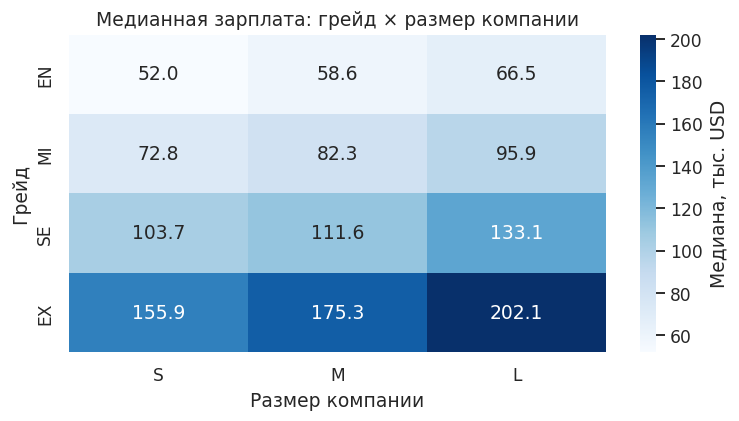

,"Разница медиан L к S, %"
experience_level,
EN,27.838
MI,31.818
SE,28.355
EX,29.678


In [21]:
grade_size=feature_eda.pivot_table(index='experience_level',columns='company_size',values='salary_usd',aggfunc='median').reindex(index=LEVELS,columns=SIZES)
grade_size_n=pd.crosstab(feature_eda.experience_level,feature_eda.company_size).reindex(index=LEVELS,columns=SIZES)
display(grade_size_n)
fig,ax=plt.subplots(figsize=(7,4))
sns.heatmap(grade_size/1000,annot=True,fmt='.1f',cmap='Blues',ax=ax,cbar_kws={'label':'Медиана, тыс. USD'})
ax.set(title='Медианная зарплата: грейд × размер компании',xlabel='Размер компании',ylabel='Грейд')
finish()
large_premium=grade_size['L']/grade_size['S']-1
display((large_premium*100).rename('Разница медиан L к S, %').to_frame())
report['interaction']=(f'Относительное превышение медианы L над S внутри грейдов лежит между '
    f'{large_premium.min()*100:.1f}% и {large_premium.max()*100:.1f}%. '
    'Это описательная разница; статистическая значимость отдельного взаимодействия здесь не проверялась.')

Относительное превышение медианы L над S внутри грейдов лежит между 27.8% и 31.8%. Это описательная разница; статистическая значимость отдельного взаимодействия здесь не проверялась.

В будущем можно сравнить модель с OHE исходных категорий и модель с добавленными взаимодействиями.
Заранее считать `senior_large` улучшением нельзя.
Сходная относительная разница во всех грейдах совместима с простым мультипликативным эффектом размера компании.
Проверить эти варианты нужно при сравнении моделей на валидации.


### 5.4. Дополнительно: проверка PCA по лекции 4
Применим PCA к пяти признакам: стажу, грейду, размеру компании, баллу соцпакета и длине описания.
Грейд и размер компании кодируем порядковыми числами.
Такое кодирование задаёт расстояния между категориями. Это допущение нужно учитывать при интерпретации.
Зарплата и признаки на её основе в PCA не участвуют.

Заполнение медианой, стандартизация и PCA обучаются только на обучающей части.
Покажем собственные значения, график каменистой осыпи и накопленную долю дисперсии.
Число компонент выберем двумя способами: по правилу Кайзера и по порогу 95% дисперсии.
Под нагрузками будем понимать **корреляции стандартизованных признаков с компонентами**.
Это отличается от коэффициентов в `components_`.
Отдельно проверим, можно ли сжать пару «стаж и грейд» в одну компоненту.


,Собственное значение,Доля дисперсии,Накопленная доля
PC1,1.926,0.385,0.385
PC2,1.018,0.204,0.589
PC3,0.999,0.200,0.789
PC4,0.983,0.197,0.985
PC5,0.074,0.015,1.000


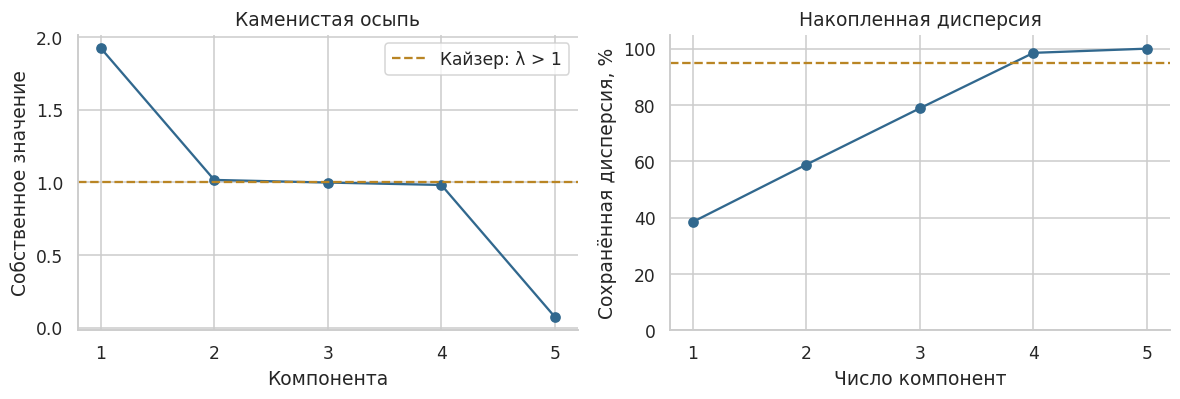

,PC1,PC2,PC3,PC4,PC5
years_experience,0.981,0.002,-0.005,0.006,0.193
exp_num,0.981,-0.002,-0.005,0.005,-0.193
size_num,-0.003,-0.636,0.447,0.629,0.000
benefits_score,-0.012,-0.337,-0.894,0.295,0.000
job_description_length,0.008,-0.707,0.025,-0.707,0.001


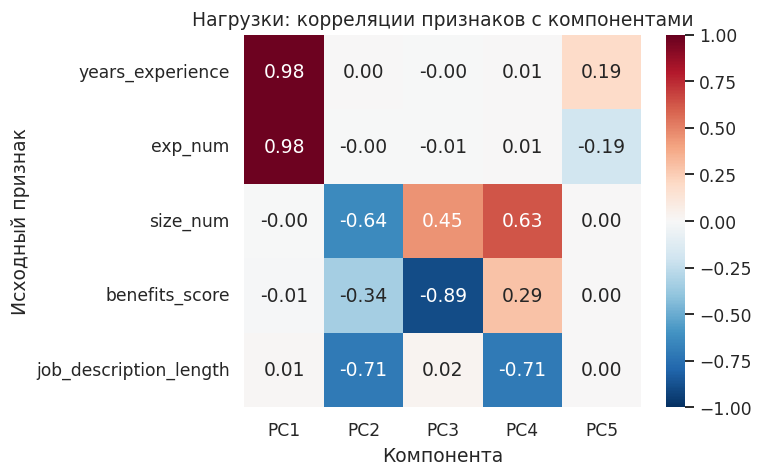

In [22]:
def pca_frame(frame):
    return frame.assign(exp_num=frame.experience_level.map(LEVEL_MAP),size_num=frame.company_size.map(SIZE_MAP))
pca_columns=['years_experience','exp_num','size_num','benefits_score','job_description_length']
pca_pipeline=Pipeline([('imputer',SimpleImputer(strategy='median')),('scaler',StandardScaler()),
                       ('pca',PCA(svd_solver='full'))])
pca_train=pca_pipeline.fit_transform(pca_frame(train)[pca_columns])
pca_test=pca_pipeline.transform(pca_frame(test)[pca_columns])
pca=pca_pipeline.named_steps['pca']
eigenvalues=pca.explained_variance_
variance=pca.explained_variance_ratio_
cumulative=np.cumsum(variance)
component_names=[f'PC{i+1}' for i in range(len(pca_columns))]
n95=int(np.searchsorted(cumulative,.95)+1)
n_kaiser=int((eigenvalues>1).sum())
display(pd.DataFrame({'Собственное значение':eigenvalues,'Доля дисперсии':variance,
                       'Накопленная доля':cumulative},index=component_names))
fig,axes=plt.subplots(1,2,figsize=(11,3.8))
axes[0].plot(range(1,6),eigenvalues,'o-',color=BLUE); axes[0].axhline(1,color=GOLD,ls='--',label='Кайзер: λ > 1')
axes[0].set(xticks=range(1,6),xlabel='Компонента',ylabel='Собственное значение',title='Каменистая осыпь'); axes[0].legend()
axes[1].plot(range(1,6),cumulative*100,'o-',color=BLUE); axes[1].axhline(95,color=GOLD,ls='--')
axes[1].set(xticks=range(1,6),ylim=(0,105),xlabel='Число компонент',ylabel='Сохранённая дисперсия, %',title='Накопленная дисперсия')
finish()
z_train=pca_pipeline.named_steps['scaler'].transform(pca_pipeline.named_steps['imputer'].transform(pca_frame(train)[pca_columns]))
loadings=np.corrcoef(z_train.T,pca_train.T)[:len(pca_columns),len(pca_columns):]
loading_table=pd.DataFrame(loadings,index=pca_columns,columns=component_names)
display(loading_table)
fig,ax=plt.subplots(figsize=(7,4.5))
sns.heatmap(loading_table,annot=True,fmt='.2f',cmap='RdBu_r',center=0,vmin=-1,vmax=1,ax=ax)
ax.set(title='Нагрузки: корреляции признаков с компонентами',xlabel='Компонента',ylabel='Исходный признак')
finish()
pair_pca=Pipeline([('scaler',StandardScaler()),('pca',PCA(n_components=1,svd_solver='full'))])
pair_train=pair_pca.fit_transform(pca_frame(train)[['years_experience','exp_num']])
pair_test=pair_pca.transform(pca_frame(test)[['years_experience','exp_num']])
pair_retained=pair_pca.named_steps['pca'].explained_variance_ratio_[0]
assert np.allclose(np.corrcoef(pca_train.T)-np.eye(5),0,atol=1e-10)
report['pca']=(f'Первые две компоненты сохраняют {cumulative[1]*100:.2f}% дисперсии пяти признаков. '
    f'Для сохранения не менее 95% нужны {n95} компоненты. Правило Кайзера оставляет {n_kaiser}. '
    f'Одна компонента пары «стаж-грейд» сохраняет {pair_retained*100:.2f}% её дисперсии.')

Первые две компоненты сохраняют 58.86% дисперсии пяти признаков. Для сохранения не менее 95% нужны 4 компоненты. Правило Кайзера оставляет 2. Одна компонента пары «стаж-грейд» сохраняет 96.27% её дисперсии.

Первая компонента в основном отражает уровень опыта.
Стаж и грейд имеют на ней большие нагрузки одного знака.
Знак компоненты произволен: его смена не меняет результат.
Другие компоненты отражают различия в размере компании, балле соцпакета и длине описания.
Данных для более подробной содержательной интерпретации этих компонент недостаточно.

Некоторые собственные значения близки к 1.
Поэтому небольшие изменения выборки могут повлиять на результат правила Кайзера.
Его стоит сопоставлять с долей сохранённой дисперсии.

Сжатие всех пяти признаков до двух теряет значительную часть разброса данных.
Для дальнейшей проверки можно заменить стаж и грейд одной компонентой.
Другой вариант: оставить один из этих двух признаков.
Высокая сохранённая дисперсия признаков **не гарантирует** сохранения информации о зарплате.
Поэтому в основную матрицу PCA пока не включаем.

Как сказано на слайде 30 лекции 4, «высокая вариативность ≠ высокая смысловая важность для конкретной исследовательской задачи».
Поэтому мы не считаем большую долю сохранённой дисперсии доказательством пользы PCA для прогноза зарплаты.
Красивое сжатие получилось, но место в итоговой модели ему ещё нужно заслужить.


### 5.5. Итоговые матрицы и проверки
Добавляем шесть новых признаков к исходным.
Обучаем `ColumnTransformer` на обучающей части.
Затем применяем его к отложенным данным и строкам без известной зарплаты.
PCA в этот вариант не входит. Его можно будет сравнить с основной обработкой в отдельном эксперименте.


In [23]:
final_preprocessor=make_preprocessor(base_numeric+new_columns,base_categorical)
X_train=final_preprocessor.fit_transform(train_fe)
X_test=final_preprocessor.transform(test_fe)
X_unknown_target=final_preprocessor.transform(create_features(unlabeled))
y_train=train.salary_usd.copy()
y_test=test.salary_usd.copy()
final_feature_names=final_preprocessor.get_feature_names_out()
checks={
    'Исходный CSV не изменён':source_sha256==hashlib.sha256(DATA_PATH.read_bytes()).hexdigest(),
    'Все строки учтены':len(train)+len(test)+len(unlabeled)==len(raw),
    'Нет пересечений компаний':not bool(set(train.company_name)&set(test.company_name)),
    'Нет пересечений job_id':not bool(set(train.job_id)&set(test.job_id)),
    'Матрицы без NaN и inf':all(np.isfinite(x).all() for x in [X_train,X_test,X_unknown_target]),
    'Одинаковое число столбцов':X_train.shape[1]==X_test.shape[1]==X_unknown_target.shape[1],
    'Таргет отсутствует в X':not any('salary_usd' in c for c in final_feature_names),
    'Наблюдаемый таргет не импутирован':y_train.equals(raw.loc[train.index,'salary_usd']) and y_test.equals(raw.loc[test.index,'salary_usd'])
}
assert all(checks.values()),checks
display(pd.Series(checks,name='Проверка пройдена'))
print('Итоговые размеры:', {'train':X_train.shape,'test':X_test.shape,'unknown_target':X_unknown_target.shape})
report['matrix']=f'Подготовлены матрицы {X_train.shape} (обучающая часть), {X_test.shape} (отложенная часть) и {X_unknown_target.shape} (неизвестная цель); все проверки выполнены.'


Исходный CSV не изменён              True
Все строки учтены                    True
Нет пересечений компаний             True
Нет пересечений job_id               True
Матрицы без NaN и inf                True
Одинаковое число столбцов            True
Таргет отсутствует в X               True
Наблюдаемый таргет не импутирован    True
Name: Проверка пройдена, dtype: bool

Итоговые размеры: {'train': (11195, 111), 'test': (3781, 111), 'unknown_target': (24, 111)}


Подготовлены матрицы (11195, 111) (обучающая часть), (3781, 111) (отложенная часть) и (24, 111) (неизвестная цель); все проверки выполнены.

### Выводы по пунктам 4–5
Даты преобразованы, варианты категорий объединены, подозрительные значения обработаны по указанным правилам.
Заполнение пропусков и масштабирование обучены только на обучающей части.
Для двух числовых признаков сравнены MinMaxScaler, StandardScaler, RobustScaler, log1p и sqrt.
Для категорий рассмотрены порядковое кодирование и OHE.
Строки без достоверной зарплаты сохранены отдельно. Целевые значения для них не придумывались.

Созданы шесть признаков и проверена их связь с зарплатой.
Их расчёт не использует целевую переменную. Пользу для прогноза ещё предстоит проверить на моделях.
Связь `senior_large` с зарплатой объясняется сочетанием уже связанных с ней грейда и размера компании.
Квадрат стажа меняет представление зависимости, сохраняя порядок наблюдений.

Стаж и грейд можно компактно представить одной главной компонентой.
При сжатии всех пяти рассмотренных признаков до двух компонент теряется заметная доля дисперсии.
Поэтому PCA изучен отдельно и не включён в основную матрицу.

Дополнительно проверена чувствительность к порогу зарплат и составлен журнал изменений.
Для шести новых признаков применена поправка Холма. Также рассмотрены сочетания грейда с размером компании и нагрузки PCA.
Выводы относятся к данному учебному файлу. Причинные связи и улучшение прогноза здесь не проверялись.

### Источники методов
Для пунктов 4–5 использованы PDF лекций 1–4 из [папки курса](https://disk.360.yandex.ru/d/k903xBTIzxMmVQ):
`Лекция1_Intro.pdf` (93 слайда), `Лекция2_EDA.pdf` (67), `Лекция3_FE.pdf` (49), `Лекция4_DR.pdf` (64).
Номера основных слайдов приведены в начале пункта 4.
Также использованы примеры масштабирования, корреляций и PCA из семинаров 2–4. Видеозаписи не использовались.

Справочные материалы: [SciPy: Kendall τ](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kendalltau.html),
[scikit-learn: StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html),
[scikit-learn: PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html),
[поправка Холма](https://www.statsmodels.org/stable/generated/statsmodels.stats.multitest.multipletests.html).

### Использование генеративных моделей
Мы любим ИИ и часто им пользуемся, но к его ответам относимся осторожно.
Для проверки результатов и редактирования использовали OpenAI Codex (GPT-6 Astra), Claude Opus 5 и Qimi K3.
Мы лично разобрали и проверили весь код. При его подготовке использовали ИИ, а при выборе методов руководствовались лекциями.
ИИ помог нам разобраться в библиотеке pandas и в работе с данными.
Не скрываем, что большую часть кода разбирали и проверяли с помощью Codex и других моделей.
Это помогало понять, как работает код, и находить простые ошибки.
В Codex запускали расчёты и проверяли, соответствуют ли выводы таблицам и графикам.
ИИ также помогал с подготовкой кода и черновых пояснений, в том числе в пунктах 4 и 5.
В тексте есть наши формулировки и варианты, предложенные ИИ, которые затем редактировались.
Исходные данные не генерировали.

Perplexity использовали для поиска справочной информации.
Материалы лекций загрузили в NotebookLM для более простого усвоения, все материалы самостоятельно просмотрели как на парах, так и после них.
Ответы моделей сопоставляли с лекциями и результатами расчётов.

**Примеры формулировок запросов:**
- «Покажи, как заполнить пропуски медианами обучающей выборки и применить те же значения к новым данным».
- «Сопоставь выводы с таблицами и графиками. Найди утверждения, которые не подтверждаются результатами».
- «Прочитай весь текст. Убери повторы и шаблонные обороты, сократи длинные предложения. Сохрани смысл и числа».
- «Проверь орфографию, пунктуацию и согласование слов. Не меняй условия задания».

Это примеры формулировок, а не дословный журнал переписки.


Комментарии к заданию и принципам его оценивания:

 - Все пункты задания должны сопровождаться _выполненным_ фрагментом кода.
 - Если результаты в виде статистических показателей, таблиц или графиков никак не прокомментированы и отсутствуют содержательные выводы на их основе, то работа оценивается в 0 баллов, в этом случае анализ данных не проведён.
 - Правильно выполненное задание оценивается в 8 баллов (отлично). Для получения более высокой оценки нужно выйти за рамки предложенного задания. В случае с текущим заданием это может быть самостоятельное изучение и применение дополнительных инструментов разведочного анализа и предобработки данных или развернутое и глубокое исследование имеющихся данных на основе использования пройденных на занятиях инструментов.
 - В задании пять пунктов. Вес первого - 10%, второго - 25%, третьего - 25%, четвертого - 20%, пятого - 20%. 
 - Задание можно выполнять индивидуально или в группе из 2 человек, критерии оценивания при этом остаются одинаковыми;
 - Если задание выполняется вдвоем, то в Smart LMS ноутбук с решениями загружает только один из студентов.
 - В названии загружаемого в Smart LMS файла нужно указать фамилию(ии) автора(ов) работы.
 - При использовании инструментов искусственного интеллекта необходимо отметить это в работе в соответствии с правилами НИУ ВШЭ.

### Этот файл нужно сохранить как Jupyter Notebook (.ipynb) и загрузить в Smart LMS до 21:00 29 сентября. Не рекомендуется загружать файл в Smart LMS в последние несколько минут перед дедлайном. После дедлайна выполненные задания не принимаются.

Мы надеемся, что проделанная работа вам понравится и вы оцените пасхалочки, которые мы оставили в этой работе 🙂